In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["NUMBA_THREADING_LAYER"
] = "workqueue"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_MAX_ACTIVE_LEVELS"] = "1"
import stark as sk


In [2]:
# ==========================================
# 0. 初始化核心数据对象 HData
# ==========================================
print(">>> 初始化 HData 对象...")
resolutions = [ 50000,500000, 1000000,]
hdata = sk.HData(
    data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
    output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
    genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
    chrom_list=[f"chr{i}" for i in range(1, 23)],
    resolutions=resolutions
)

>>> 初始化 HData 对象...


In [3]:
hdata

HData object with 0 cells and 0 metacells
    resolutions: [50000, 500000, 1000000]
    obs: []
    views_pca: []
    views_umap: []
    views_embedding: []
    views_mat: []
    views_is: []
    uns keys: []

In [4]:
# ==========================================
# 1. 执行数据预处理与加载
# ==========================================
print("\n>>> 1. 执行数据预处理与加载...")
sk.pp.process_and_load(
    hdata, 
    force_process=True, 
    cpu_num=10, 
    gpu_num=8
)


>>> 1. 执行数据预处理与加载...
====== calculating depth =======
Depth file already exists. Skipping depth calculation.
====== depth calculation completed =======
====== Processing multiple resolutions =======
====== Processing resolution: 50000 =======
Files for resolution 50000 already exist. Skipping processing.
====== Processing resolution: 500000 =======
Files for resolution 500000 already exist. Skipping processing.
====== Processing resolution: 1000000 =======
Files for resolution 1000000 already exist. Skipping processing.
✅ 数据底层处理 (stark_process) 完成。
✅ 数据已成功挂载到 HData 对象中。


In [5]:
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])

In [6]:
hdata.obs['label'] = lb

In [7]:
hdata

HData object with 700 cells and 0 metacells
    resolutions: [50000, 500000, 1000000]
    obs: ['depth', 'label']
    views_pca: [50000, 500000, 1000000]
    views_umap: [50000, 500000, 1000000]
    views_embedding: [50000, 500000, 1000000]
    views_mat: [50000, 500000, 1000000]
    views_is: []
    uns keys: []

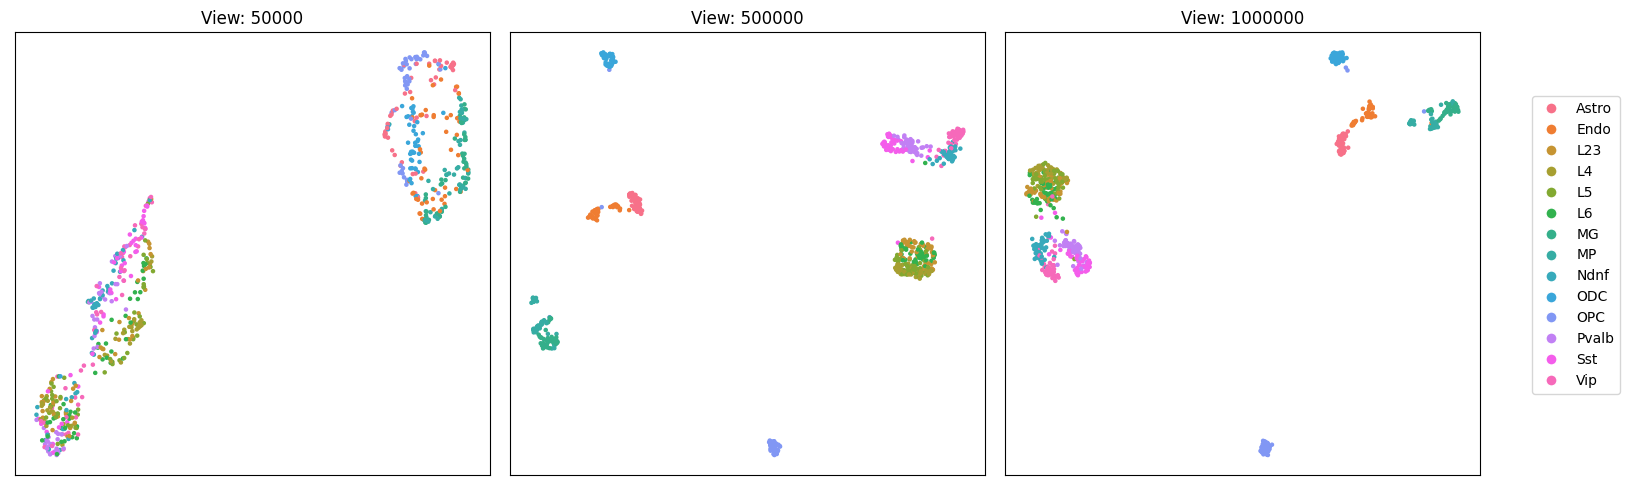

In [8]:
sk.pl.plot_views(hdata)

mean_depth:0.11M


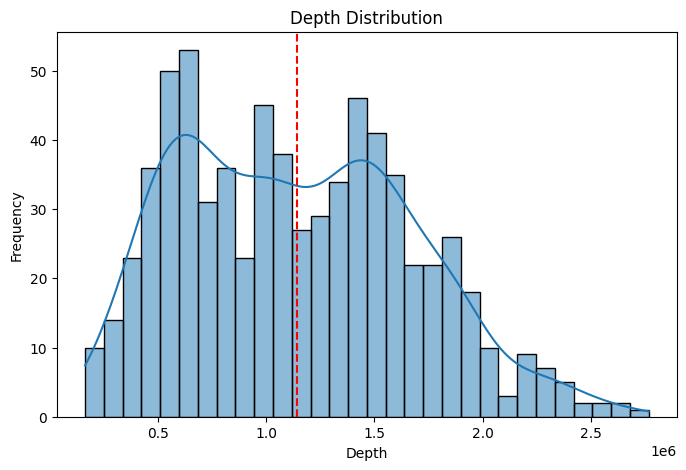

In [9]:
sk.pl.plot_depth_distribution(hdata)


>>> 2. 推荐 MetaCell 数量...
推荐 MetaCell 数量的目标测序深度范围: 10000000.00 - 100000000.00
正在构建 AnnData 并计算近邻图 (n_neighbors=30)...
正在执行 Leiden 聚类 (resolution=1.5)...
✅ 聚类完成，共发现 10 个聚类簇。

💡 基于 Leiden 聚类的推荐结果: 最终总 n_metacells 范围 = [11, 50]


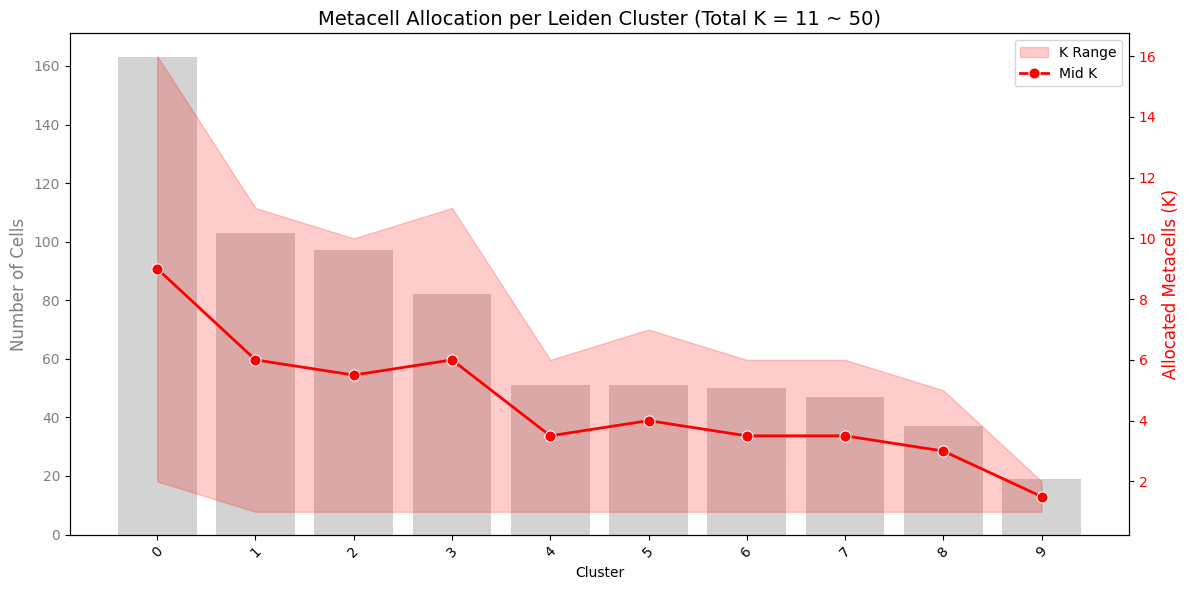

In [10]:
# ==========================================
# 2. 推荐 MetaCell 数量 (带原有参数)
# ==========================================
print("\n>>> 2. 推荐 MetaCell 数量...")
min_depth = 10000000
max_depth = 100000000
print(f"推荐 MetaCell 数量的目标测序深度范围: {min_depth:.2f} - {max_depth:.2f}")
min_k, max_k = sk.tl.recommend_metacell_num(
    hdata,
    target_depth_min=min_depth,  # 下限 20M
    target_depth_max=max_depth ,  # 上限 40M
    resolution_param=1.5,     # Leiden resolution
    n_neighbors=30,
    ref_view=500000,
    
)

In [16]:
# # ==========================================
# # 3. 初始化模型参数 (还原所有原有超参数)
# # ==========================================
# print("\n>>> 3. 初始化模型参数...")
sk.tl.init_model(
    hdata, 
    n_metacells=20 , # 25,            # 目标 MetaCell 数量
    lambda_balance=0.1,       # 平衡惩罚
    lambda_consistency=0.010,  # 一致性惩罚
adaptive_weight=True,
    max_iter=100,              # 最大迭代次数
    # --- scHi-C 深度优化参数 ---
    min_size_threshold=0.002,  # 重生阈值
    respawn_interval=100,       # 检查频率
    split_metric='pca',         # 分裂准则
    weight_method='awp'
    # weight_momentum=0.99,
)


✅ 模型参数初始化完成，目标 MetaCell 数量: 20


In [17]:
# ==========================================
# 4. 计算核矩阵
# ==========================================
print("\n>>> 4. 计算核矩阵...")
sk.tl.compute_kernels(hdata, )
# sk.tl.compute_kernels(hdata, use_ps=True)
# sk.tl.compute_kernels(hdata, use_ps=False)÷


>>> 4. 计算核矩阵...
步骤1: 构建核矩阵 (Cache Dir: None)
  [View 0] 开始内部计算 RBF 核矩阵 (Input: (700, 68))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:89: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  [View 1] 开始内部计算 RBF 核矩阵 (Input: (700, 114))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:89: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  [View 2] 开始内部计算 RBF 核矩阵 (Input: (700, 123))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:89: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)



>>> 5. 初始化 Waypoints (K-Means++)...

步骤2: 参数初始化 (Method: Micro-Clustering on PCA features)
  执行 MiniBatchKMeans (k=300)...
  最终选中 20 个 Waypoints


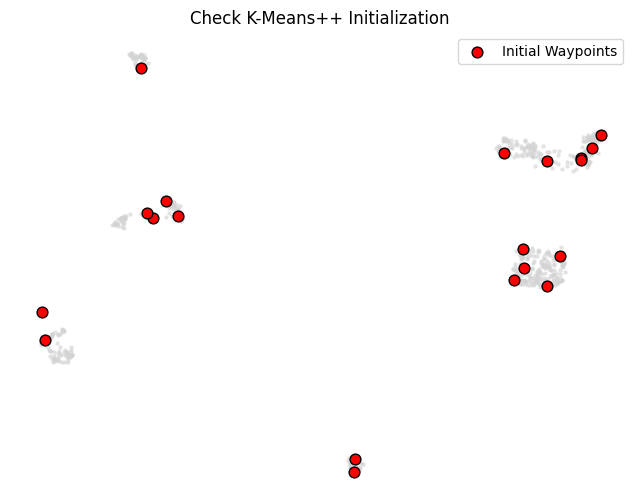

In [18]:
# ==========================================
# 5. 初始化 Waypoint (还原原有初始化参数)
# ==========================================
print("\n>>> 5. 初始化 Waypoints (K-Means++)...")
sk.tl.initialize_waypoints(
    hdata, 
    data_type='pca', 
    seed=32, 
    n_micro_clusters=300,       # 对应原代码中的 30
    ref_view_res=1000000
)
sk.pl.plot_initialization(hdata,resolution=500000, title="Check K-Means++ Initialization")



In [19]:
# ==========================================
# 6. 核心拟合优化
# ==========================================
print("\n>>> 6. 开始模型拟合优化...")
sk.tl.fit(hdata, n_threads=10)


>>> 6. 开始模型拟合优化...

步骤4: 联合优化 (Split Metric: pca)
Iter   0 | Loss: 1727.9382 | Size Range: 28.0-41.4 | weight: [0.33333333 0.33333333 0.33333333]
Iter  10 | Loss: 1496.4424 | Size Range: 30.7-39.1 | weight: [0.28006966 0.36950675 0.35042359]
Iter  20 | Loss: 1496.0889 | Size Range: 25.5-36.9 | weight: [0.25824564 0.38389065 0.3578637 ]
Iter  30 | Loss: 1493.8361 | Size Range: 30.3-38.3 | weight: [0.25153265 0.38860573 0.35986162]
Iter  40 | Loss: 1488.2426 | Size Range: 28.9-38.5 | weight: [0.24989851 0.38985973 0.36024175]
Iter  50 | Loss: 1488.2407 | Size Range: 28.7-37.5 | weight: [0.24829419 0.38943114 0.36227467]
Iter  60 | Loss: 1492.0270 | Size Range: 28.8-38.1 | weight: [0.24764465 0.39194551 0.36040983]
Iter  70 | Loss: 1495.4141 | Size Range: 32.0-38.7 | weight: [0.24791641 0.3900217  0.36206189]
Iter  80 | Loss: 1489.4181 | Size Range: 32.6-37.1 | weight: [0.24701846 0.39186716 0.36111437]
Iter  90 | Loss: 1495.0923 | Size Range: 30.3-37.0 | weight: [0.24699192 0.39278171 0


>>> 7-10. 绘图与评估...


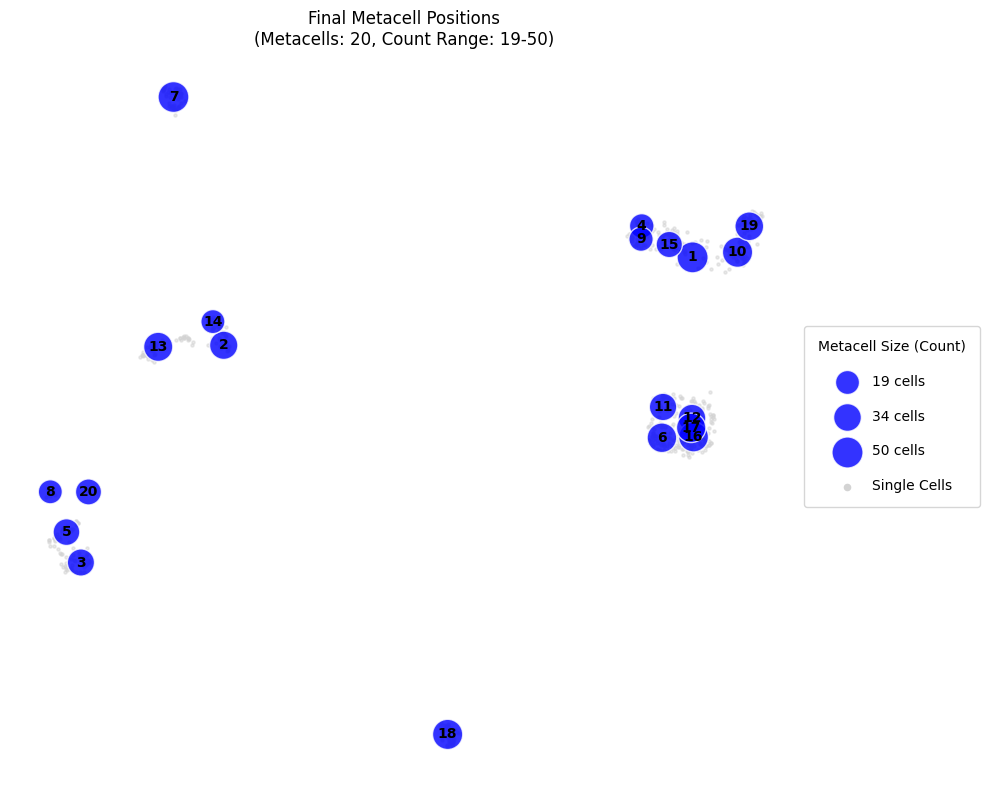

In [20]:


# ==========================================
# 7 - 10. 后续评估与可视化
# ==========================================
print("\n>>> 7-10. 绘图与评估...")
sk.pl.plot_metacells(hdata, resolution=500000, max_size=500, min_size=300,show_idx=True)



正在计算评估指标...
✅ 指标计算完成！(发现 14 种细胞类型)
----------------------------------------
简单平均纯度 (Mean Purity)  : 0.7563
模型准确率 (Accuracy)      : 0.7429
全局加权分 (Global Score)  : 0.6012
过度融合指标 (WCOS)       : 0.9586
Hub 权重不纯度 (HWIS)     : 0.9858
----------------------------------------
✅ 评估指标计算完成，纯度得分(EP_v2等)已同步至 hdata.metacells。


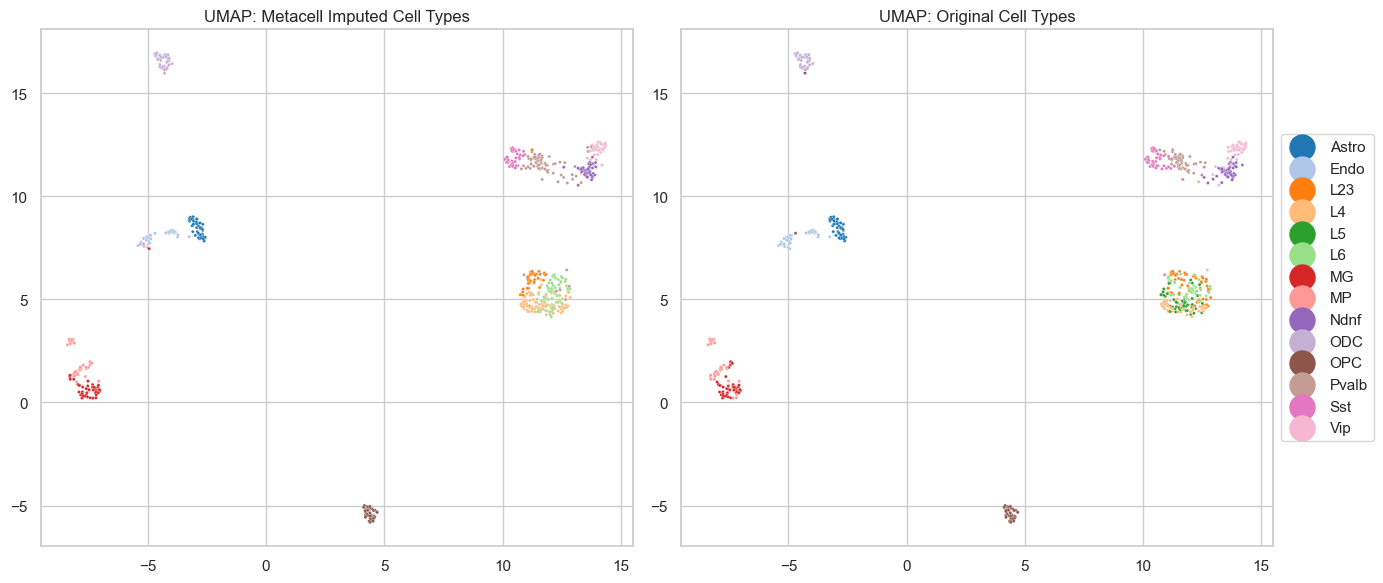


🎉 全流程运行完毕！


In [56]:
# 执行评估
purity_df, metrics = sk.tl.evaluate(hdata, hdata.obs['label'])

# 最终对比图
sk.pl.plot_umap_comparison(hdata, resolution=500000)

print("\n🎉 全流程运行完毕！")

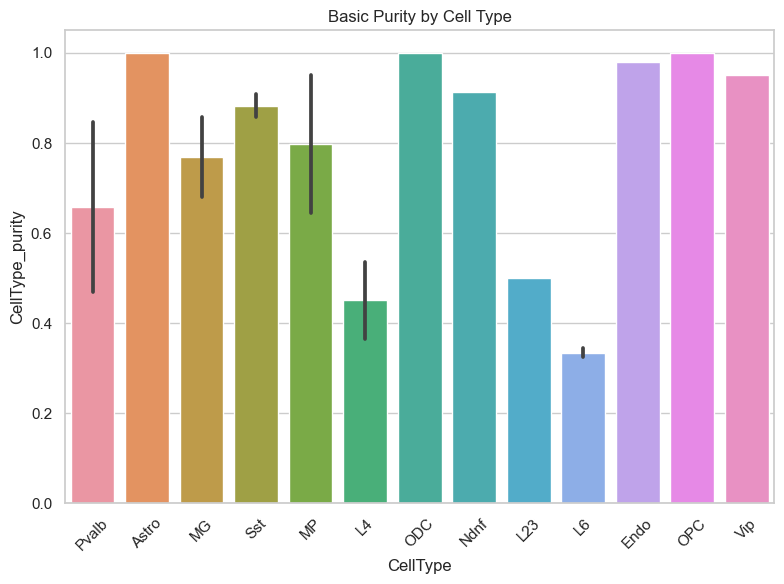

In [57]:
sk.pl.plot_basic_purity(hdata,)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


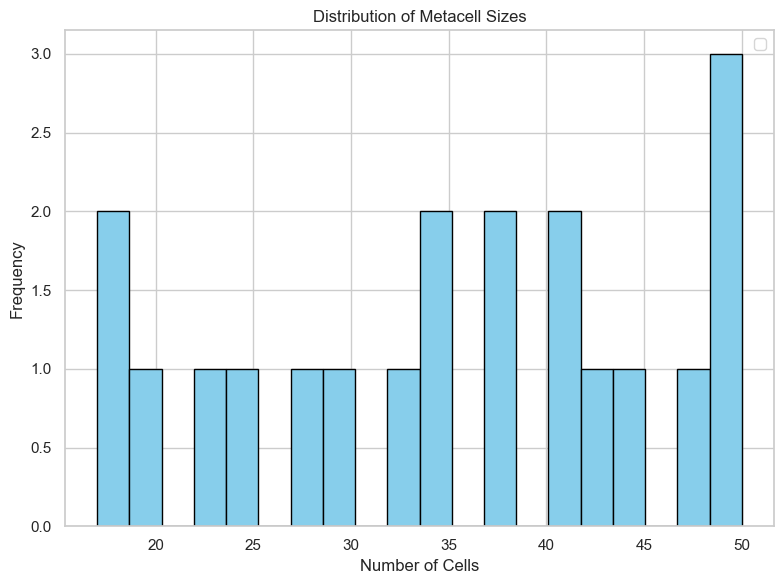

In [50]:
sk.pl.plot_metacell_sizes(hdata,)

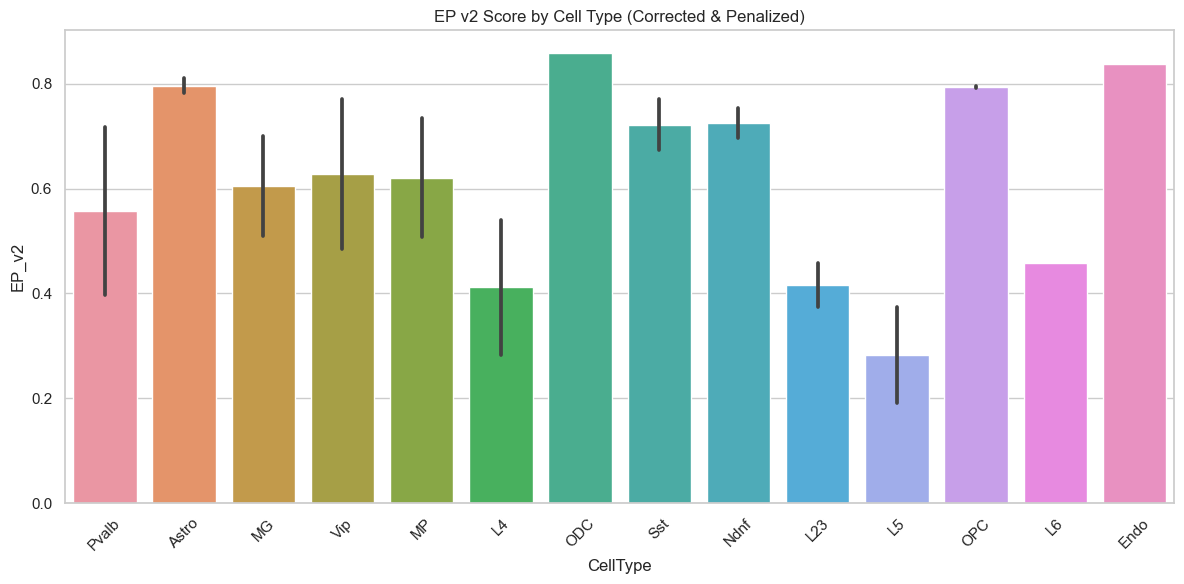

In [27]:
sk.pl.plot_ep_score(hdata)

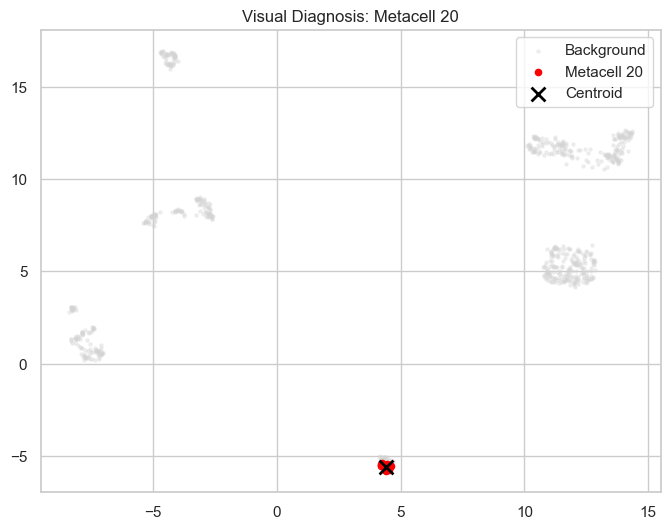

In [28]:
sk.pl.plot_specific_metacell(hdata, metacell_id=20, resolution=500000)


In [42]:
chrom = 'chr3'
resolution = 50000
start =0
end=198022430//4

In [ ]:
sk.tl.aggregate_metacell_pairs(hdata,  n_jobs=2, force_aggregate=False, 
                             convert_to_cool=True, convert_to_mcool=True,
                             resolution=10000, mcool_resolutions=[ 50000, 100000,500000, 1000000,2000000], verbose=True)

# ,2000000

>>> 未检测到基础属性或被强制刷新，正在统计 Metacell 属性...
>>> 分配发生改变或被强制重跑，正在重新聚合并覆盖历史 pairs 文件...


Aggregating Pairs: 100%|██████████| 25/25 [01:09<00:00,  2.80s/it]


开始转换为 .cool (分辨率: 10000, 并行数: 2)...


Pairs -> Cool 10000:  60%|██████    | 3/5 [00:31<00:20, 10.05s/it]

⏭️  分辨率 50000 已存在聚合结果，跳过 (使用 force_aggregate=True 强制重跑)。
⏭️  分辨率 500000 已存在聚合结果，跳过 (使用 force_aggregate=True 强制重跑)。
⏭️  分辨率 1000000 已存在聚合结果，跳过 (使用 force_aggregate=True 强制重跑)。

✅ 全量聚合完成！
   可通过 base_on='mat' 方式可视化的分辨率: [50000, 500000, 1000000]
   调用示例: sk.pl.plot_metacell_heatmap(hdata, ..., resolution=50000, base_on='mat')
共找到 1 个属于 'OPC' 的 Metacells, 准备渲染...


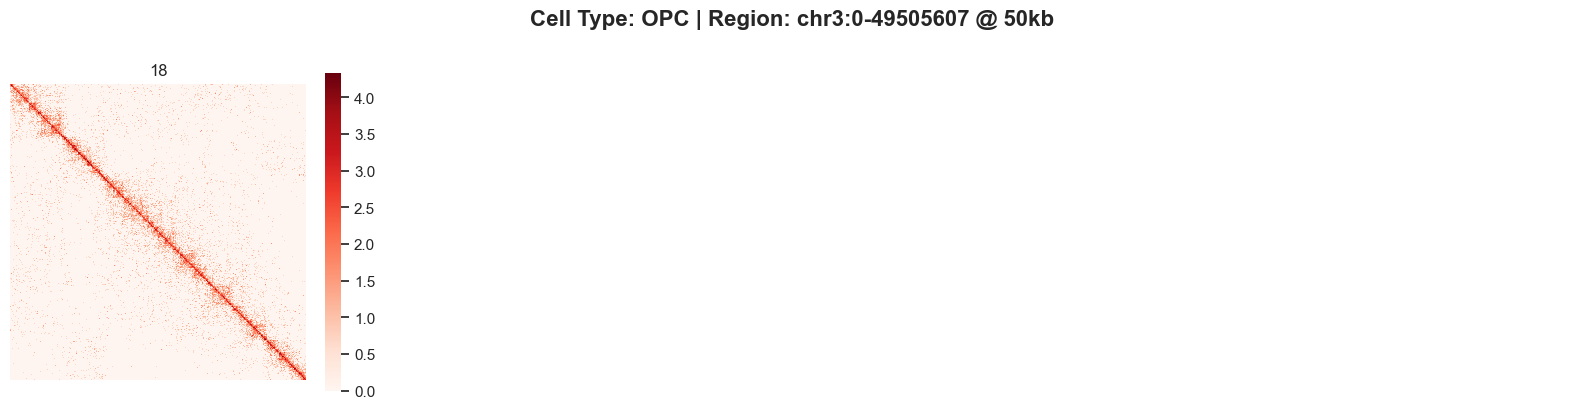

In [ ]:
# 1. 直接全内存聚合生成 mat (不需要跑 pair/cool/mcool)
sk.tl.aggregate_metacell_mat(hdata, )

# 2. 画图验证 (通过 base_on="mat" 一键路由)
sk.pl.plot_celltype_heatmaps(hdata, cell_type='OPC', chrom=chrom, 
                                start=start, 
                                end=end, 
                                resolution=resolution, 
                                base_on='mat',
                                cell_type_col='dominant_label',balance=False)


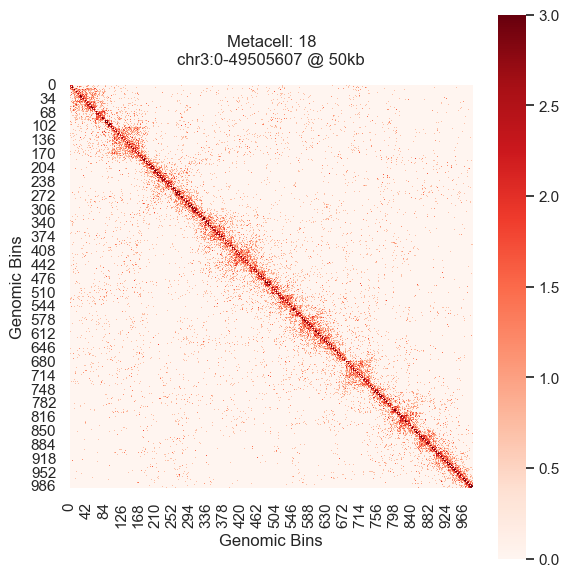

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 2.30258509, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.30258509, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 3.4339872 ,
        2.48490665],
       [0.        , 0.        , 0.        , ..., 3.4339872 , 0.        ,
        3.09104245],
       [0.        , 0.        , 0.        , ..., 2.48490665, 3.09104245,
        0.        ]])

In [ ]:
sk.pl.plot_metacell_heatmap(hdata=hdata,
                            metacell_id=18,
                            chrom=chrom,
                            start=start,
                            end=end,
                            resolution=resolution,
                            balance=False,
                            base_on='pair',
                            log1p=True,
                            vmax=3,
                            fill_diagonal_zero=True)

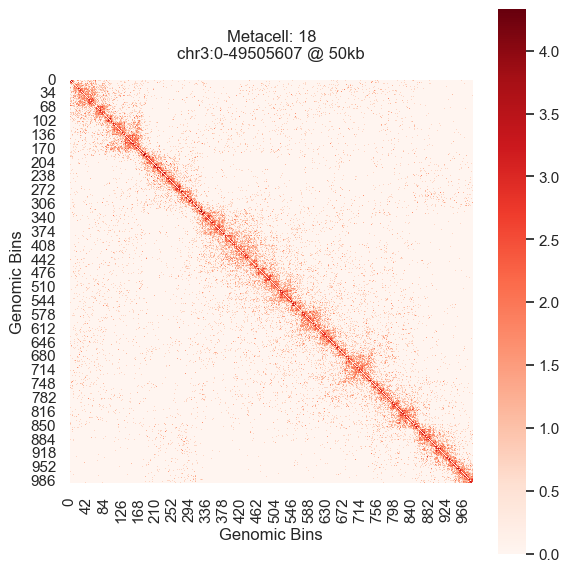

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 2.6390574, ..., 0.       , 0.       ,
        0.       ],
       [0.       , 2.6390574, 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 3.0910425,
        2.0794415],
       [0.       , 0.       , 0.       , ..., 3.0910425, 0.       ,
        2.5649493],
       [0.       , 0.       , 0.       , ..., 2.0794415, 2.5649493,
        0.       ]], dtype=float32)

In [ ]:
sk.pl.plot_metacell_heatmap(hdata=hdata, 
                            metacell_id=18,
                            chrom=chrom,
                            balance=False,
                            resolution=resolution,
                            start=start,
                            log1p=True,
                            end=end,
                            base_on='mat',            # 【关键】使用极速的内存矩阵模式_)
)
